<a href="https://colab.research.google.com/github/salgudekomal945-ops/Data_Scattering/blob/main/Seaborn_charts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

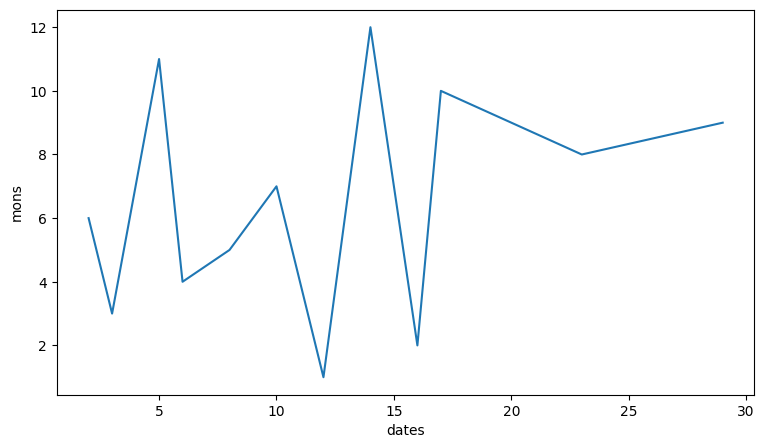

In [5]:
plt.figure(figsize = (9,5))
date = [12,16,3,6,8,2,10,23,29,17,5,14]
mon = [1,2,3,4,5,6,7,8,9,10,11,12]
df = pd.DataFrame({'dates':date,'mons':mon})
sns.lineplot(x='dates',y='mons',data=df)
plt.show()

In [6]:
df = pd.read_csv('/content/Weather1.csv')

In [7]:
df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [8]:
df.shape

(8784, 8)

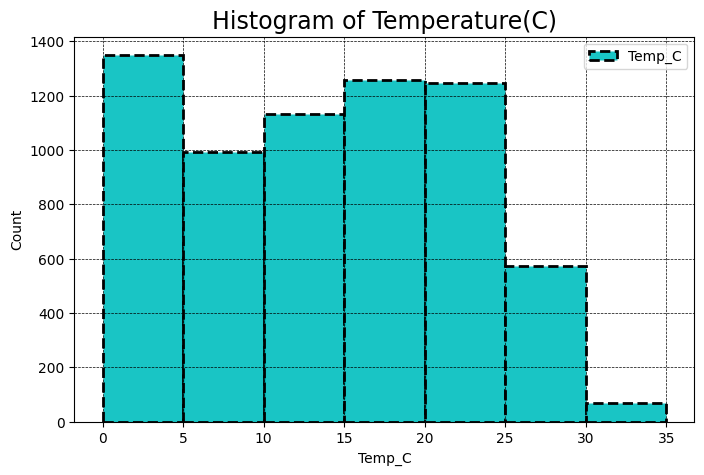

In [14]:
plt.figure(figsize = (8,5))
bins = np.arange(0,40,5)
sns.histplot(df['Temp_C'], bins  = bins, kde=False,
            color='c', edgecolor='k', linewidth=2, linestyle='--', alpha=0.9,
             label = 'Temp_C')

plt.title("Histogram of Temperature(C)", fontsize = 17)
plt.xticks(bins)
plt.grid(color = 'k',linestyle = "--",linewidth = 0.5)
plt.legend()
plt.show()

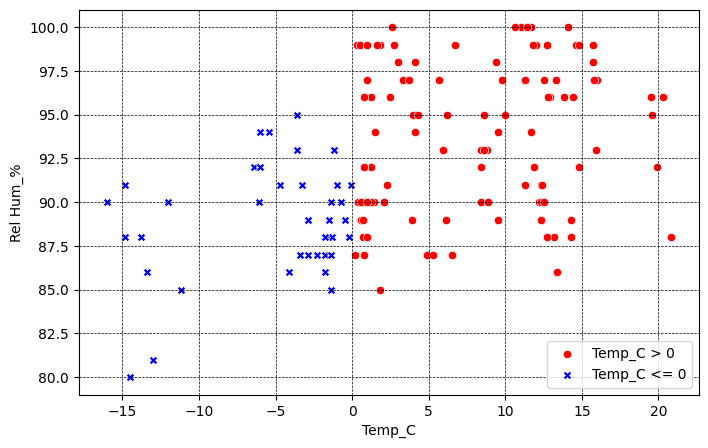

In [20]:
df1 = df[df['Weather'] == 'Fog']
df1_positive_temp = df1[df1['Temp_C'] > 0]
df1_negative_temp = df1[df1['Temp_C'] <= 0]

plt.figure(figsize = (8,5))
sns.scatterplot(x='Temp_C', y='Rel Hum_%', data=df1_positive_temp, color='red', label='Temp_C > 0', marker='o')
sns.scatterplot(x='Temp_C', y='Rel Hum_%', data=df1_negative_temp, color='blue', label='Temp_C <= 0', marker='X')

plt.grid(color = 'k',linestyle = "--",linewidth = 0.5)
plt.legend(loc = 4)
plt.show()

In [22]:
#Heatmap Plot
# Explicitly select all relevant numerical columns for correlation
new = df1[['Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km', 'Press_kPa']]
new.head()

,Visibility_km,Press_kPa,Weather
Date/Time,,,
1/1/2012 0:00,8.0,101.24,Fog
1/1/2012 1:00,8.0,101.24,Fog
1/1/2012 4:00,4.8,101.23,Fog
1/1/2012 5:00,6.4,101.27,Fog
1/1/2012 6:00,6.4,101.29,Fog


In [23]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 0 to 8722
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         150 non-null    object 
 1   Temp_C            150 non-null    float64
 2   Dew Point Temp_C  150 non-null    float64
 3   Rel Hum_%         150 non-null    int64  
 4   Wind Speed_km/h   150 non-null    int64  
 5   Visibility_km     150 non-null    float64
 6   Press_kPa         150 non-null    float64
 7   Weather           150 non-null    object 
dtypes: float64(4), int64(2), object(2)
memory usage: 10.5+ KB


In [32]:
#Heatmap Plot
new = df1[['Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km', 'Press_kPa']]
new.head()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
0,-1.8,-3.9,86,4,8.0,101.24
1,-1.8,-3.7,87,4,8.0,101.24
4,-1.5,-3.3,88,7,4.8,101.23
5,-1.4,-3.3,87,9,6.4,101.27
6,-1.5,-3.1,89,7,6.4,101.29


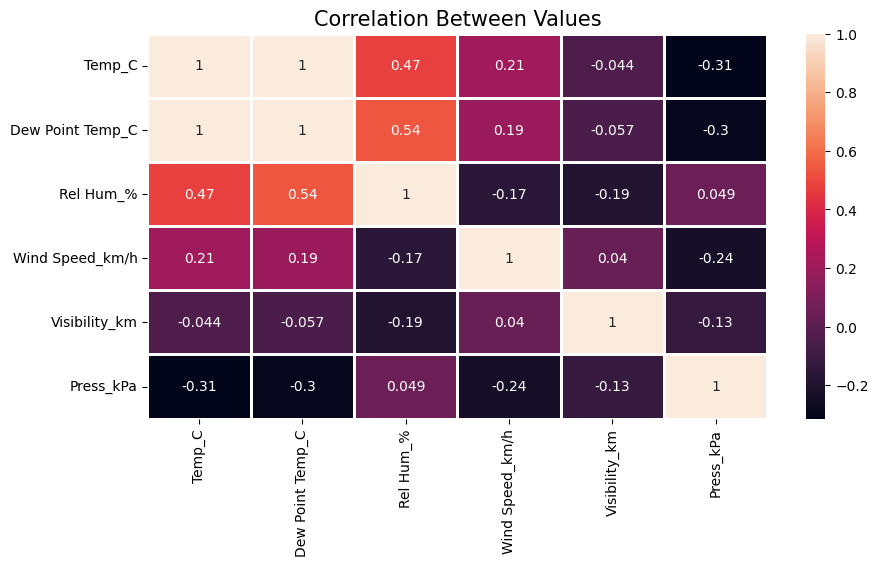

In [31]:
plt.figure(figsize = (10,5))
sns.heatmap(new.corr(), annot=True, linewidth = 1)
plt.title('Correlation Between Values', fontsize=15)
plt.show()